#Independence testing





In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.spatial.distance import cdist
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mutual_info_score
from sklearn.feature_selection import mutual_info_regression
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})
COLORS = plt.cm.tab10.colors
print('All imports successful')

All imports successful



## 1   Test Implementations

In [ ]:

# KERNELs

def _median_bandwidth(X):
    """RBF_LAplace"""
    dists = cdist(X.reshape(-1,1) if X.ndim==1 else X,
                  X.reshape(-1,1) if X.ndim==1 else X)
    return np.median(dists[dists > 0])

def kernel_linear(X, Y=None):
    X = X.reshape(-1,1) if X.ndim==1 else X
    Y = X if Y is None else (Y.reshape(-1,1) if Y.ndim==1 else Y)
    return X @ Y.T

def kernel_rbf(X, Y=None, sigma=None):
    X = X.reshape(-1,1) if X.ndim==1 else X
    Y = X if Y is None else (Y.reshape(-1,1) if Y.ndim==1 else Y)
    sigma = sigma or _median_bandwidth(X)
    D = cdist(X, Y, 'sqeuclidean')
    return np.exp(-D / (2 * sigma**2))

def kernel_polynomial(X, Y=None, degree=3, c=1):
    X = X.reshape(-1,1) if X.ndim==1 else X
    Y = X if Y is None else (Y.reshape(-1,1) if Y.ndim==1 else Y)
    return (X @ Y.T + c) ** degree

def kernel_laplace(X, Y=None, sigma=None):
    X = X.reshape(-1,1) if X.ndim==1 else X
    Y = X if Y is None else (Y.reshape(-1,1) if Y.ndim==1 else Y)
    sigma = sigma or _median_bandwidth(X)
    D = cdist(X, Y, 'minkowski', p=1)
    return np.exp(-D / sigma)

KERNEL_REGISTRY = {
    'Linear':      kernel_linear,
    'RBF':         kernel_rbf,
    'Polynomial':  kernel_polynomial,
    'Laplace':     kernel_laplace,
}


def hsic(X, Y, kernel_x='rbf', kernel_y='rbf', n_perm=200):
    
    n = len(X)
    kx_fn = KERNEL_REGISTRY.get(kernel_x, kernel_rbf) if isinstance(kernel_x, str) else kernel_x
    ky_fn = KERNEL_REGISTRY.get(kernel_y, kernel_rbf) if isinstance(kernel_y, str) else kernel_y
    
    Kx = kx_fn(X)
    Ky = ky_fn(Y)
    
    # centrer
    H = np.eye(n) - np.ones((n, n)) / n
    Kxc = H @ Kx @ H
    Kyc = H @ Ky @ H
    
    stat = np.trace(Kxc @ Kyc) / (n - 1)**2
    
    # pval
    null = []
    for _ in range(n_perm):
        idx = np.random.permutation(n)
        Kyp = Ky[idx][:, idx]
        Kycp = H @ Kyp @ H
        null.append(np.trace(Kxc @ Kycp) / (n - 1)**2)
    p = np.mean(np.array(null) >= stat)
    return stat, p


def partial_correlation_test(data_matrix, i, j):
    """
    Test independence of variables i and j , uses the precision matrix
    """
    n, p = data_matrix.shape
    cov = np.cov(data_matrix, rowvar=False)
    try:
        prec = np.linalg.inv(cov)          #precision matrix = Ω
    except np.linalg.LinAlgError:
        prec = np.linalg.pinv(cov)
    pcor = -prec[i, j] / np.sqrt(prec[i, i] * prec[j, j])
    # t-statistic with df = n - p -2
    df = n - p - 2
    if df < 1: df = 1
    t  = pcor * np.sqrt(df / (1 - pcor**2 + 1e-12))
    p  = 2 * stats.t.sf(np.abs(t), df)
    return pcor, p

#perm test
def permutation_test(X, Y, statistic_fn=None, n_perm=1000):
   
    if statistic_fn is None:
        statistic_fn = lambda a, b: stats.pearsonr(a, b)[0]**2
    obs = statistic_fn(X, Y)
    null = [statistic_fn(X, np.random.permutation(Y)) for _ in range(n_perm)]
    p = np.mean(np.array(null) >= obs)
    return obs, p

#MI
def mutual_information_test(X, Y, n_neighbors=5, n_perm=200):
    
    mi = mutual_info_regression(X.reshape(-1,1), Y, n_neighbors=n_neighbors)[0]
    null = [mutual_info_regression(np.random.permutation(X).reshape(-1,1), Y,
                                    n_neighbors=n_neighbors)[0]
            for _ in range(n_perm)]
    p = np.mean(np.array(null) >= mi)
    return mi, p

#dist corr
def _dmat(X):

    X = X.reshape(-1,1) if X.ndim==1 else X
    A = cdist(X, X)
    row = A.mean(axis=1, keepdims=True)
    col = A.mean(axis=0, keepdims=True)
    grand = A.mean()
    return A - row - col + grand

def distance_correlation_test(X, Y, n_perm=500):

    n = len(X)
    Ac, Bc = _dmat(X), _dmat(Y)
    dcov2 = (Ac * Bc).mean()
    dvar_x = (Ac * Ac).mean()
    dvar_y = (Bc * Bc).mean()
    dcor = np.sqrt(max(dcov2, 0) / np.sqrt(max(dvar_x * dvar_y, 1e-12)))
    
    null = []
    for _ in range(n_perm):
        idx = np.random.permutation(n)
        Bcp = Bc[idx][:, idx]
        dv2 = (Ac * Bcp).mean()
        null.append(np.sqrt(max(dv2, 0) / np.sqrt(max(dvar_x * dvar_y, 1e-12))))
    p = np.mean(np.array(null) >= dcor)
    return dcor, p

#d stat hoeffding
def hoeffding_d(X, Y):

    stat, p = stats.kendalltau(X, Y)   
    try:
        from scipy.stats import hoeffd
        res = hoeffd(X, Y)
        return res.statistic, res.pvalue
    except ImportError:
        return stat, p   

#test pipeline
def run_all_tests(X, Y, data_matrix=None, i=0, j=1, n_perm=300, verbose=True):
    
    results = []  

    r, p = stats.pearsonr(X, Y)
    results.append(('Pearson r', r, p, 'Classical'))
    
    r, p = stats.spearmanr(X, Y)
    results.append(('Spearman ρ', r, p, 'Rank'))

    r, p = stats.kendalltau(X, Y)
    results.append(('Kendall τ', r, p, 'Rank'))

    for kname in ['Linear', 'RBF', 'Polynomial', 'Laplace']:
        stat, p = hsic(X, Y, kernel_x=kname, kernel_y=kname, n_perm=n_perm)
        results.append((f'HSIC ({kname})', stat, p, 'Kernel'))

    dc, p = distance_correlation_test(X, Y, n_perm=n_perm)
    results.append(('dCor', dc, p, 'Distance'))

    mi, p = mutual_information_test(X, Y, n_perm=n_perm)
    results.append(('Mutual Info (KSG)', mi, p, 'Info Theory'))

    stat, p = permutation_test(X, Y, n_perm=n_perm)
    results.append(('Permutation (r²)', stat, p, 'Permutation'))

    if data_matrix is not None:
        pc, p = partial_correlation_test(data_matrix, i, j)
        results.append(('Partial Corr', pc, p, 'Precision'))
    
    df = pd.DataFrame(results, columns=['Test', 'Statistic', 'p-value', 'Category'])
    df['Reject H₀ (α=0.05)'] = df['p-value'] < 0.05
    df['Statistic'] = df['Statistic'].round(5)
    df['p-value']   = df['p-value'].round(4)
    return df

print('Test functions defined')

Test functions defined



## 2  Synthetic Dataset A; Simple Structure

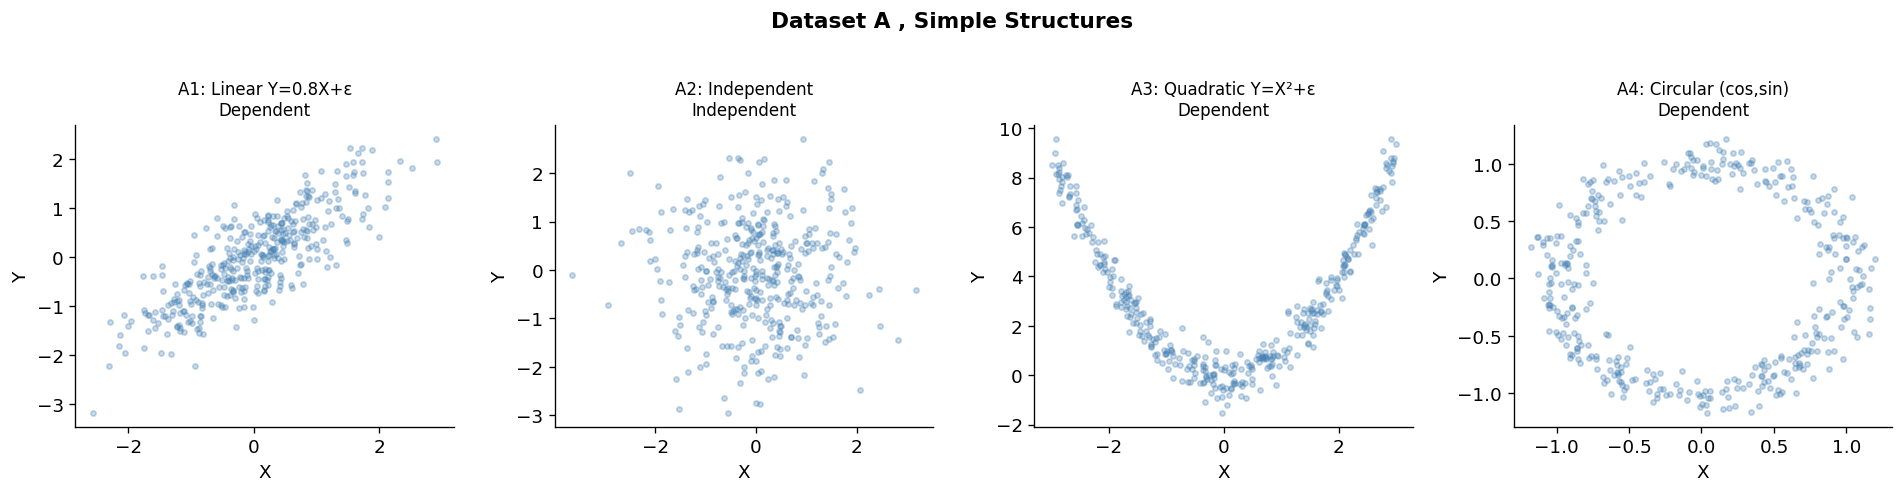

In [3]:
N = 400
rng = np.random.default_rng(42)

# Y = 0.8X + ε
A1_x = rng.normal(0, 1, N)
A1_y = 0.8 * A1_x + rng.normal(0, 0.5, N)

# Scenario A2: Independent Gaussians
A2_x = rng.normal(0, 1, N)
A2_y = rng.normal(0, 1, N)

# Y = X² + ε  
A3_x = rng.uniform(-3, 3, N)
A3_y = A3_x**2 + rng.normal(0, 0.5, N)

# Circular (sin/cos)
theta = rng.uniform(0, 2*np.pi, N)
A4_x = np.cos(theta) + rng.normal(0, 0.1, N)
A4_y = np.sin(theta) + rng.normal(0, 0.1, N)

scenarios_A = [
    ('A1: Linear Y=0.8X+ε',  A1_x, A1_y, True),
    ('A2: Independent',       A2_x, A2_y, False),
    ('A3: Quadratic Y=X²+ε', A3_x, A3_y, True),
    ('A4: Circular (cos,sin)',A4_x, A4_y, True),
]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (name, x, y, dep) in zip(axes, scenarios_A):
    ax.scatter(x, y, alpha=0.3, s=10, color='steelblue')
    label = 'Dependent' if dep else 'Independent'
    ax.set_title(f'{name}\n{label}', fontsize=10)
    ax.set_xlabel('X'); ax.set_ylabel('Y')
plt.suptitle('Dataset A , Simple Structures', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 2.1 Run All Tests on Dataset A

In [4]:
results_A = {}
for name, x, y, _ in scenarios_A:
    dm = np.column_stack([x, y])
    results_A[name] = run_all_tests(x, y, data_matrix=dm, i=0, j=1, n_perm=300)
    print(name)
    display(results_A[name])

A1: Linear Y=0.8X+ε


,Test,Statistic,p-value,Category,Reject H₀ (α=0.05)
0,Pearson r,0.82482,0.0,Classical,True
1,Spearman ρ,0.80370,0.0,Rank,True
2,Kendall τ,0.61348,0.0,Rank,True
3,HSIC (Linear),0.49714,0.0,Kernel,True
4,HSIC (RBF),0.04002,0.0,Kernel,True
5,HSIC (Polynomial),73.21877,0.0,Kernel,True
6,HSIC (Laplace),0.02269,0.0,Kernel,True
7,dCor,0.77920,0.0,Distance,True
8,Mutual Info (KSG),0.55958,0.0,Info Theory,True
9,Permutation (r²),0.68032,0.0,Permutation,True


A2: Independent


,Test,Statistic,p-value,Category,Reject H₀ (α=0.05)
0,Pearson r,-0.00465,0.9261,Classical,False
1,Spearman ρ,-0.00097,0.9845,Rank,False
2,Kendall τ,0.00030,0.9928,Rank,False
3,HSIC (Linear),0.00002,0.9267,Kernel,False
4,HSIC (RBF),0.00024,0.8767,Kernel,False
5,HSIC (Polynomial),0.60430,0.8067,Kernel,False
6,HSIC (Laplace),0.00081,0.5767,Kernel,False
7,dCor,0.07501,0.7867,Distance,False
8,Mutual Info (KSG),0.02845,0.0867,Info Theory,False
9,Permutation (r²),0.00002,0.9300,Permutation,False


A3: Quadratic Y=X²+ε


,Test,Statistic,p-value,Category,Reject H₀ (α=0.05)
0,Pearson r,0.01938,0.6992,Classical,False
1,Spearman ρ,0.02496,0.6187,Rank,False
2,Kendall τ,0.01882,0.5740,Rank,False
3,HSIC (Linear),0.00861,0.7233,Kernel,False
4,HSIC (RBF),0.03042,0.0000,Kernel,True
5,HSIC (Polynomial),573453.79450,0.0000,Kernel,True
6,HSIC (Laplace),0.02793,0.0000,Kernel,True
7,dCor,0.47905,0.0000,Distance,True
8,Mutual Info (KSG),1.54746,0.0000,Info Theory,True
9,Permutation (r²),0.00038,0.7400,Permutation,False


A4: Circular (cos,sin)


,Test,Statistic,p-value,Category,Reject H₀ (α=0.05)
0,Pearson r,0.00656,0.8960,Classical,False
1,Spearman ρ,0.00160,0.9746,Rank,False
2,Kendall τ,0.00393,0.9064,Rank,False
3,HSIC (Linear),0.00001,0.8767,Kernel,False
4,HSIC (RBF),0.00715,0.0000,Kernel,True
5,HSIC (Polynomial),0.15373,0.0000,Kernel,True
6,HSIC (Laplace),0.00943,0.0000,Kernel,True
7,dCor,0.18489,0.0000,Distance,True
8,Mutual Info (KSG),0.75529,0.0000,Info Theory,True
9,Permutation (r²),0.00004,0.8867,Permutation,False


## Heatmap  p-values across Dataset A

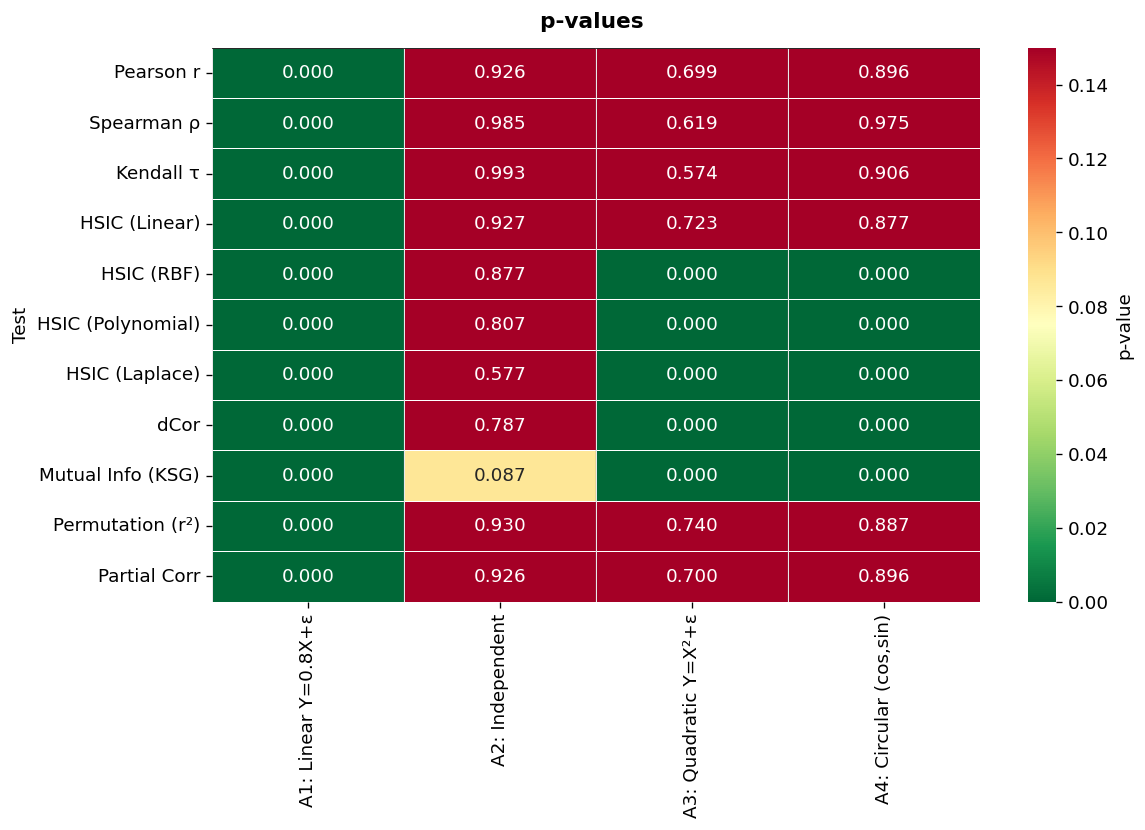

Number of tests rejecting H0 per scenario:
A1: Linear Y=0.8X+ε       11
A2: Independent            0
A3: Quadratic Y=X²+ε       5
A4: Circular (cos,sin)     5


In [5]:
def pvalue_heatmap(results_dict, title):
    pv = pd.DataFrame({k: df.set_index('Test')['p-value'] for k, df in results_dict.items()})
    fig, ax = plt.subplots(figsize=(len(pv.columns)*2.5, len(pv)*0.55 + 1))
    sns.heatmap(pv, ax=ax, cmap='RdYlGn_r', vmin=0, vmax=0.15,
                annot=True, fmt='.3f', linewidths=0.5,
                cbar_kws={'label': 'p-value'})
    ax.axhline(0, color='k', lw=0.5)
    for col_idx in range(len(pv.columns)):
        ax.axvline(col_idx, color='gray', lw=0.2)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=12)
    ax.set_xlabel('')
    plt.tight_layout()
    plt.show()
    reject = (pv < 0.05).sum(axis=0)
    print('Number of tests rejecting H0 per scenario:')
    print(reject.to_string())

pvalue_heatmap(results_A, 'p-values ')

### 2.3 HSIC Kernel Comparison on Dataset A

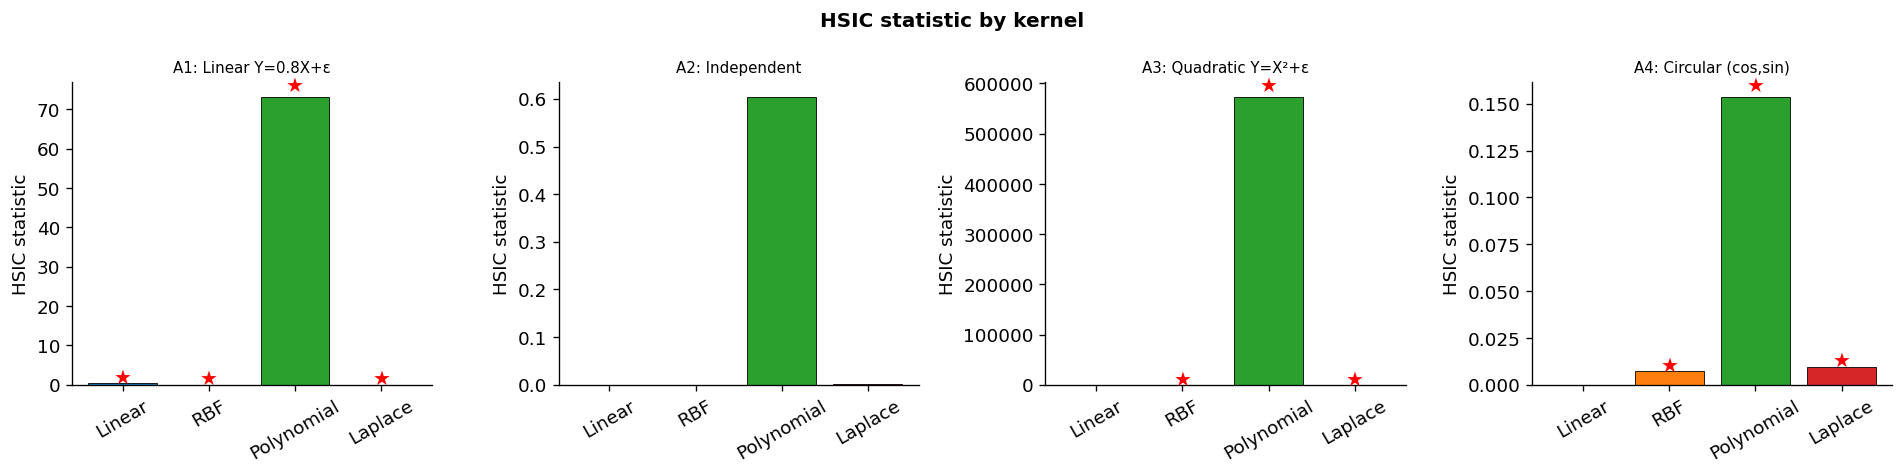

In [6]:
kernel_names = ['Linear', 'RBF', 'Polynomial', 'Laplace']

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=False)
for ax, (name, x, y, dep) in zip(axes, scenarios_A):
    stats_vals = []
    pvals = []
    for kname in kernel_names:
        s, p = hsic(x, y, kernel_x=kname, kernel_y=kname, n_perm=300)
        stats_vals.append(s)
        pvals.append(p)
    bars = ax.bar(kernel_names, stats_vals,
                  color=[COLORS[i] for i in range(4)],
                  edgecolor='black', linewidth=0.5)
    for bar, p in zip(bars, pvals):
        if p < 0.05:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() * 1.02, '★',
                    ha='center', fontsize=12, color='red')
    ax.set_title(name, fontsize=9)
    ax.set_ylabel('HSIC statistic')
    ax.tick_params(axis='x', rotation=30)
plt.suptitle('HSIC statistic by kernel', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## 3 Synthetic Dataset B

These scenarios are designed to fool classical tests while revealing the power of nonlinear methods.

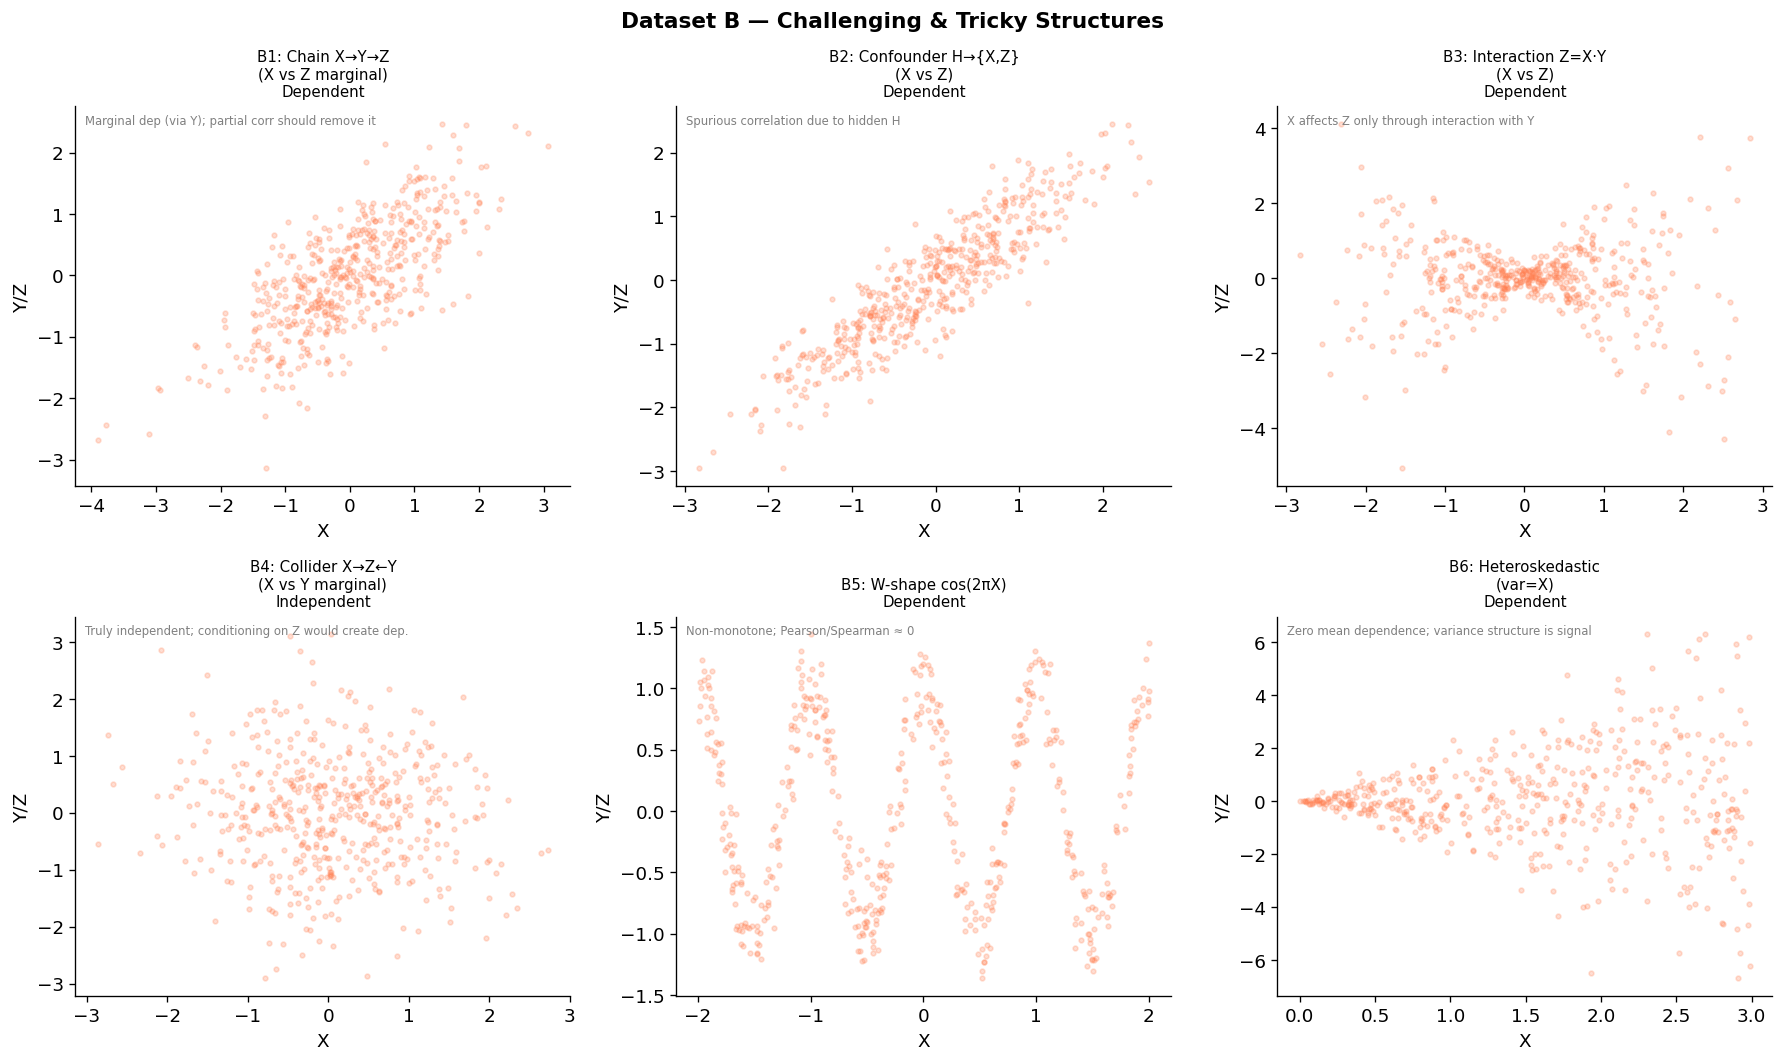

In [7]:
rng = np.random.default_rng(0)
N = 500

#X → Y → Z  (test X⊥Z | Y)
B1_x = rng.normal(0, 1, N)
B1_y = 0.8 * B1_x + rng.normal(0, 0.5, N)
B1_z = 0.8 * B1_y + rng.normal(0, 0.5, N)


#X ← H → Z
B2_h = rng.normal(0, 1, N)           # hidden confounder
B2_x = 0.9 * B2_h + rng.normal(0, 0.3, N)
B2_z = 0.9 * B2_h + rng.normal(0, 0.3, N)


#Z = X*Y
B3_x = rng.normal(0, 1, N)
B3_y = rng.normal(0, 1, N)           # independent of X
B3_z = B3_x * B3_y + rng.normal(0, 0.2, N)


# V-structure (collider)  X → Z ← Y 
B4_x = rng.normal(0, 1, N)
B4_y = rng.normal(0, 1, N)
B4_z = B4_x + B4_y + rng.normal(0, 0.3, N)  # collider


# Non-monotone (W-shape)
B5_x = rng.uniform(-2, 2, N)
B5_y = np.cos(2*np.pi*B5_x) + rng.normal(0, 0.2, N)


# Heteroskedastic
B6_x = rng.uniform(0, 3, N)
B6_y = rng.normal(0, B6_x, N)       # mean = 0, std = X


scenarios_B = [
    ('B1: Chain X→Y→Z\n(X vs Z marginal)',     B1_x, B1_z, True,
     'Marginal dep (via Y); partial corr should remove it'),
    ('B2: Confounder H→{X,Z}\n(X vs Z)',       B2_x, B2_z, True,
     'Spurious correlation due to hidden H'),
    ('B3: Interaction Z=X·Y\n(X vs Z)',        B3_x, B3_z, True,
     'X affects Z only through interaction with Y'),
    ('B4: Collider X→Z←Y\n(X vs Y marginal)', B4_x, B4_y, False,
     'Truly independent; conditioning on Z would create dep.'),
    ('B5: W-shape cos(2πX)',                   B5_x, B5_y, True,
     'Non-monotone; Pearson/Spearman ≈ 0'),
    ('B6: Heteroskedastic\n(var=X)',            B6_x, B6_y, True,
     'Zero mean dependence; variance structure is signal'),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, (name, x, y, dep, note) in zip(axes.flat, scenarios_B):
    ax.scatter(x, y, alpha=0.25, s=8, color='coral')
    label = 'Dependent' if dep else 'Independent'
    ax.set_title(f'{name}\n{label}', fontsize=9)
    ax.set_xlabel('X'); ax.set_ylabel('Y/Z')
    ax.text(0.02, 0.98, note, transform=ax.transAxes,
            fontsize=7, va='top', color='gray', wrap=True)
plt.suptitle('Dataset B — Challenging & Tricky Structures', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.1 Run All Tests on Dataset B

In [8]:
results_B = {}
for name, x, y, dep, _ in scenarios_B:
    dm = np.column_stack([x, y])
    results_B[name] = run_all_tests(x, y, data_matrix=dm, i=0, j=1, n_perm=300)
    truth = 'Dependent' if dep else 'Independent'
    print(f'\n {name.replace(chr(10)," ")}  [{truth}]')
    display(results_B[name])


 B1: Chain X→Y→Z (X vs Z marginal)  [Dependent]


,Test,Statistic,p-value,Category,Reject H₀ (α=0.05)
0,Pearson r,0.72984,0.0,Classical,True
1,Spearman ρ,0.70333,0.0,Rank,True
2,Kendall τ,0.51383,0.0,Rank,True
3,HSIC (Linear),0.45411,0.0,Kernel,True
4,HSIC (RBF),0.02743,0.0,Kernel,True
5,HSIC (Polynomial),145.94356,0.0,Kernel,True
6,HSIC (Laplace),0.01506,0.0,Kernel,True
7,dCor,0.67457,0.0,Distance,True
8,Mutual Info (KSG),0.37869,0.0,Info Theory,True
9,Permutation (r²),0.53267,0.0,Permutation,True



 B2: Confounder H→{X,Z} (X vs Z)  [Dependent]


,Test,Statistic,p-value,Category,Reject H₀ (α=0.05)
0,Pearson r,0.90519,0.0,Classical,True
1,Spearman ρ,0.90265,0.0,Rank,True
2,Kendall τ,0.72770,0.0,Rank,True
3,HSIC (Linear),0.74647,0.0,Kernel,True
4,HSIC (RBF),0.05782,0.0,Kernel,True
5,HSIC (Polynomial),117.03671,0.0,Kernel,True
6,HSIC (Laplace),0.03403,0.0,Kernel,True
7,dCor,0.87997,0.0,Distance,True
8,Mutual Info (KSG),0.89142,0.0,Info Theory,True
9,Permutation (r²),0.81938,0.0,Permutation,True



 B3: Interaction Z=X·Y (X vs Z)  [Dependent]


...

,Test,Statistic,p-value,Category,Reject H₀ (α=0.05)
0,Pearson r,-0.07922,0.0768,Classical,False
1,Spearman ρ,-0.04731,0.2910,Rank,False
2,Kendall τ,-0.03157,0.2914,Rank,False
3,HSIC (Linear),0.00594,0.0600,Kernel,False
4,HSIC (RBF),0.00031,0.5800,Kernel,False
5,HSIC (Polynomial),2.49512,0.0633,Kernel,False
6,HSIC (Laplace),0.00062,0.6733,Kernel,False
7,dCor,0.08152,0.3367,Distance,False
8,Mutual Info (KSG),0.00000,1.0000,Info Theory,False
9,Permutation (r²),0.00628,0.0800,Permutation,False



 B5: W-shape cos(2πX)  [Dependent]


,Test,Statistic,p-value,Category,Reject H₀ (α=0.05)
0,Pearson r,-0.01573,0.7257,Classical,False
1,Spearman ρ,-0.02080,0.6427,Rank,False
2,Kendall τ,-0.01350,0.6519,Rank,False
3,HSIC (Linear),0.00018,0.7767,Kernel,False
4,HSIC (RBF),0.00009,0.9433,Kernel,False
5,HSIC (Polynomial),0.06228,0.5767,Kernel,False
6,HSIC (Laplace),0.00299,0.0000,Kernel,True
7,dCor,0.12880,0.0067,Distance,True
8,Mutual Info (KSG),0.71582,0.0000,Info Theory,True
9,Permutation (r²),0.00025,0.7100,Permutation,False



 B6: Heteroskedastic (var=X)  [Dependent]


,Test,Statistic,p-value,Category,Reject H₀ (α=0.05)
0,Pearson r,0.02505,0.5762,Classical,False
1,Spearman ρ,0.01827,0.6837,Rank,False
2,Kendall τ,0.01619,0.5884,Rank,False
3,HSIC (Linear),0.00162,0.5833,Kernel,False
4,HSIC (RBF),0.01606,0.0000,Kernel,True
5,HSIC (Polynomial),2511.91188,0.0033,Kernel,True
6,HSIC (Laplace),0.01154,0.0000,Kernel,True
7,dCor,0.36966,0.0000,Distance,True
8,Mutual Info (KSG),0.37852,0.0000,Info Theory,True
9,Permutation (r²),0.00063,0.5833,Permutation,False


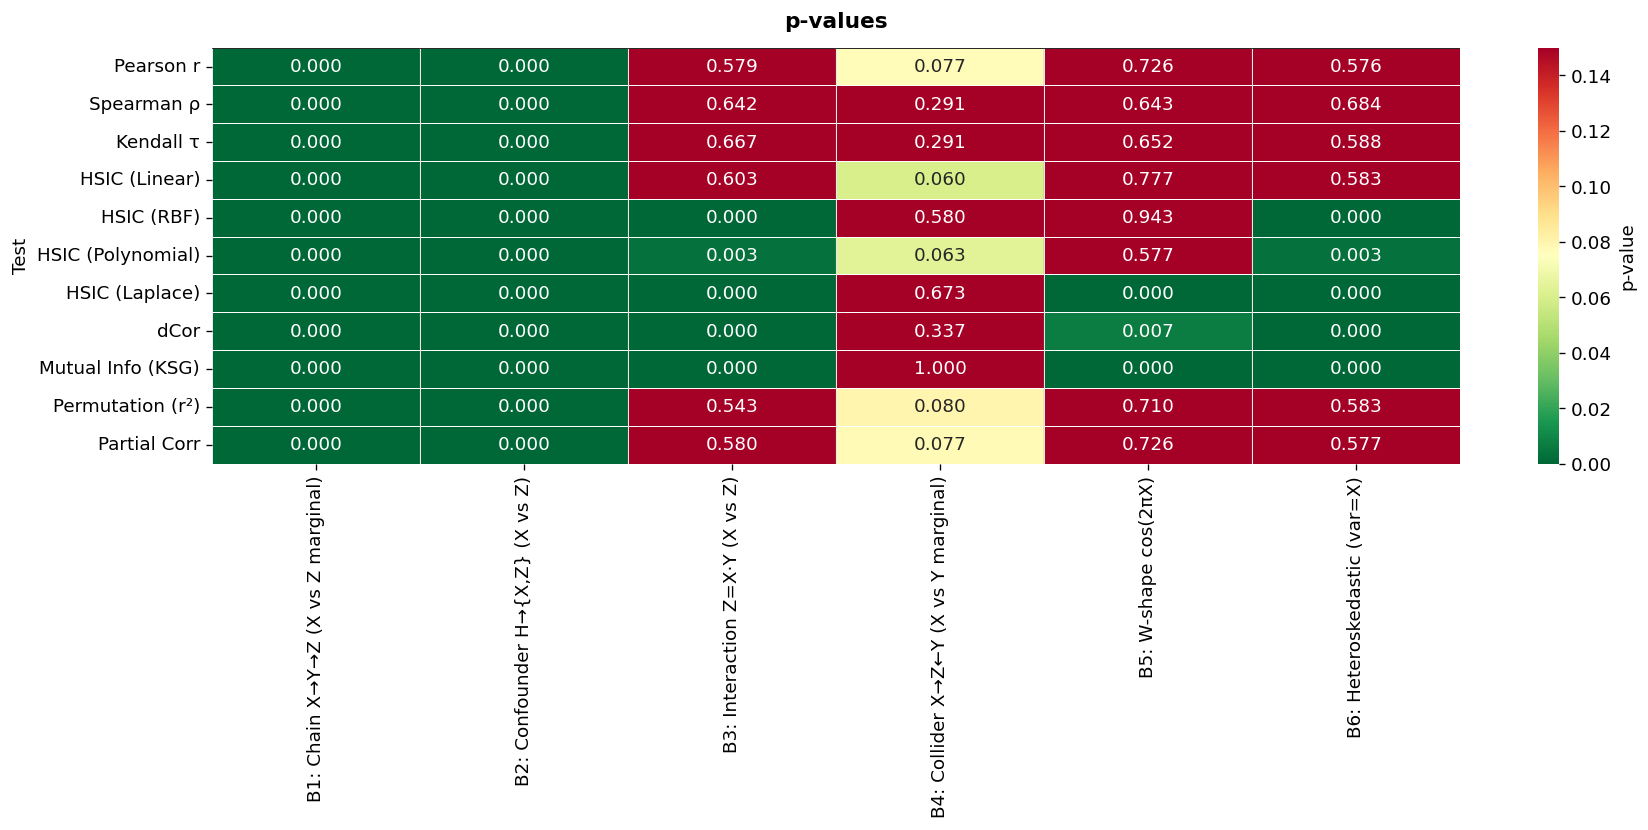

Number of tests rejecting H0 per scenario:
B1: Chain X→Y→Z (X vs Z marginal)       11
B2: Confounder H→{X,Z} (X vs Z)         11
B3: Interaction Z=X·Y (X vs Z)           5
B4: Collider X→Z←Y (X vs Y marginal)     0
B5: W-shape cos(2πX)                     3
B6: Heteroskedastic (var=X)              5


In [9]:
pvalue_heatmap(
    {k.replace('\n',' '): v for k, v in results_B.items()},
    'p-values'
)


## 4  Chain X → Y → Z

X → Y → Z

Testing X ⊥ Z
  Pearson:          r=0.730,  p=0.0000
  HSIC (RBF):       s=0.02743, p=0.0000

Testing X ⊥ Z | Y 
  Partial corr (X,Z|Y): pcor=0.0343, p=0.4453
  Partial corr (X,Y):   pcor=0.6832, p=0.0000


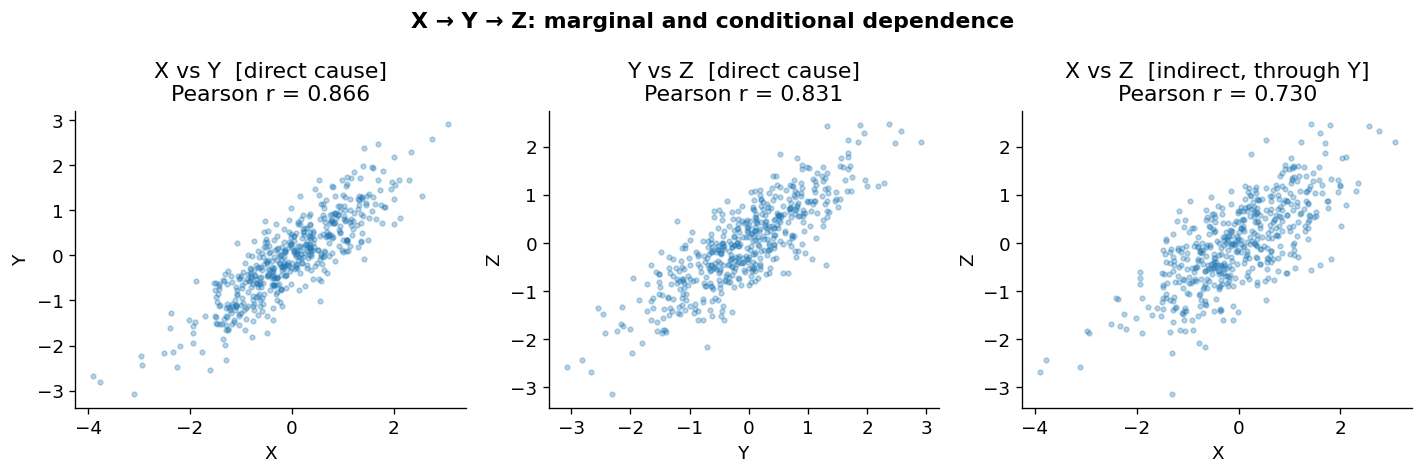

In [10]:

print('X → Y → Z')
print()
print('Testing X ⊥ Z')
print(f'  Pearson:          r={stats.pearsonr(B1_x,B1_z)[0]:.3f},  p={stats.pearsonr(B1_x,B1_z)[1]:.4f}')
print(f'  HSIC (RBF):       s={hsic(B1_x,B1_z,"RBF","RBF",200)[0]:.5f}, p={hsic(B1_x,B1_z,"RBF","RBF",200)[1]:.4f}')

print()
print('Testing X ⊥ Z | Y ')
dm3 = np.column_stack([B1_x, B1_y, B1_z])
pc_xz, p_xz = partial_correlation_test(dm3, i=0, j=2)   # X vs Z conditioning on Y
print(f'  Partial corr (X,Z|Y): pcor={pc_xz:.4f}, p={p_xz:.4f}')
pc_xy, p_xy = partial_correlation_test(dm3, i=0, j=1)   # X vs Y
print(f'  Partial corr (X,Y):   pcor={pc_xy:.4f}, p={p_xy:.4f}')

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (xa, ya, lbl) in zip(axes, [
    (B1_x, B1_y, 'X vs Y  [direct cause]'),
    (B1_y, B1_z, 'Y vs Z  [direct cause]'),
    (B1_x, B1_z, 'X vs Z  [indirect, through Y]'),
]):
    ax.scatter(xa, ya, alpha=0.3, s=8)
    r = np.corrcoef(xa, ya)[0,1]
    ax.set_title(f'{lbl}\nPearson r = {r:.3f}')
    ax.set_xlabel(lbl.split()[0]); ax.set_ylabel(lbl.split()[2])
plt.suptitle('X → Y → Z: marginal and conditional dependence', fontweight='bold')
plt.tight_layout()
plt.show()


## 5 V-structure (Collider Bias)

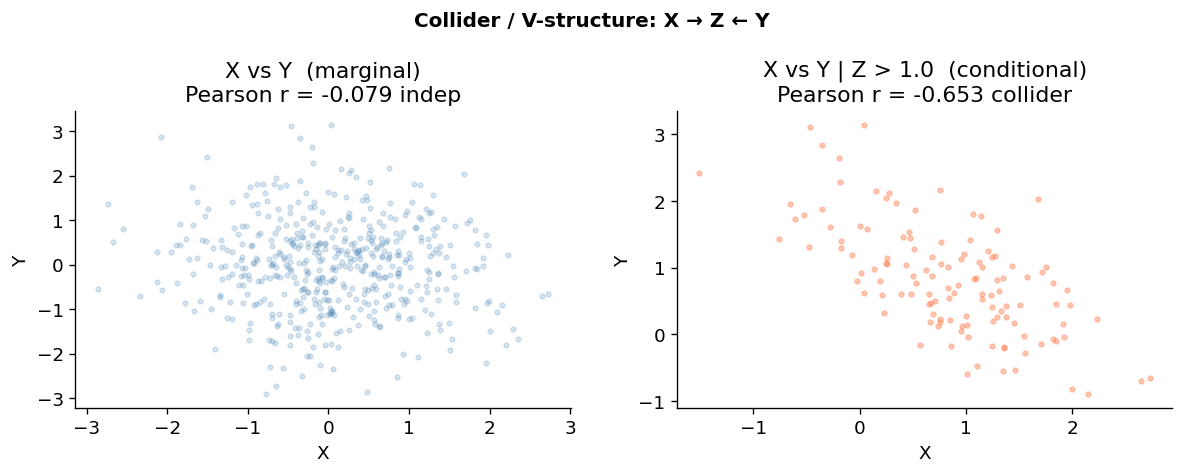

Marginal  independence tests:
  Pearson: r=-0.079, p=0.077
  HSIC (RBF): s=0.00031, p=0.570

Conditional on Z>p75 (125 points):
  Pearson: r=-0.653, p=0.0000  : dependence induced by collider


In [11]:
# Collider: X → Z ← Y
# Condition on high Z values (Z > 75th percentile)
threshold = np.percentile(B4_z, 75)
mask = B4_z > threshold

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(B4_x, B4_y, alpha=0.2, s=8, color='steelblue')
r_marg = np.corrcoef(B4_x, B4_y)[0,1]
axes[0].set_title(f'X vs Y  (marginal)\nPearson r = {r_marg:.3f} indep')

axes[1].scatter(B4_x[mask], B4_y[mask], alpha=0.4, s=8, color='coral')
r_cond = np.corrcoef(B4_x[mask], B4_y[mask])[0,1]
axes[1].set_title(f'X vs Y | Z > {threshold:.1f}  (conditional)\nPearson r = {r_cond:.3f} collider')

for ax in axes:
    ax.set_xlabel('X'); ax.set_ylabel('Y')

plt.suptitle('Collider / V-structure: X → Z ← Y', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('Marginal  independence tests:')
r, p = stats.pearsonr(B4_x, B4_y)
print(f'  Pearson: r={r:.3f}, p={p:.3f}')
s, p = hsic(B4_x, B4_y, 'RBF', 'RBF', 300)
print(f'  HSIC (RBF): s={s:.5f}, p={p:.3f}')
print(f'\nConditional on Z>p75 ({mask.sum()} points):')
r, p = stats.pearsonr(B4_x[mask], B4_y[mask])
print(f'  Pearson: r={r:.3f}, p={p:.4f}  : dependence induced by collider')


## 6 Heteroskedasticity, Zero Mean, Non-zero Dependence

In [12]:
# Y ~ N(0, X), mean=0 everywhere, but variance grows with X

print('Heteroskedastic case: Y ~ N(0, X)')
print()
tests = [
    ('Pearson r',            lambda: stats.pearsonr(B6_x, B6_y)),
    ('Spearman ρ',           lambda: stats.spearmanr(B6_x, B6_y)),
    ('HSIC Linear',          lambda: hsic(B6_x, B6_y, 'Linear', 'Linear', 300)),
    ('HSIC RBF',             lambda: hsic(B6_x, B6_y, 'RBF', 'RBF', 300)),
    ('HSIC Polynomial',      lambda: hsic(B6_x, B6_y, 'Polynomial', 'Polynomial', 300)),
    ('HSIC Laplace',         lambda: hsic(B6_x, B6_y, 'Laplace', 'Laplace', 300)),
    ('dCor',                 lambda: distance_correlation_test(B6_x, B6_y, 300)),
    ('Mutual Info (KSG)',    lambda: mutual_information_test(B6_x, B6_y, n_perm=300)),
    ('Permutation (r²)',     lambda: permutation_test(B6_x, B6_y, n_perm=300)),
]

rows = []
for name, fn in tests:
    s, p = fn()
    rows.append({'Test': name, 'Statistic': round(s,5), 'p-value': round(p,4),
                 'Detects?': 'YES' if p < 0.05 else 'NO'})
display(pd.DataFrame(rows))

Heteroskedastic case: Y ~ N(0, X)



,Test,Statistic,p-value,Detects?
0,Pearson r,0.02505,0.5762,NO
1,Spearman ρ,0.01827,0.6837,NO
2,HSIC Linear,0.00162,0.5767,NO
3,HSIC RBF,0.01606,0.0000,YES
4,HSIC Polynomial,2511.91188,0.0000,YES
5,HSIC Laplace,0.01154,0.0000,YES
6,dCor,0.36966,0.0000,YES
7,Mutual Info (KSG),0.37852,0.0000,YES
8,Permutation (r²),0.00063,0.5533,NO



## 7 Sensitivity Analysis 

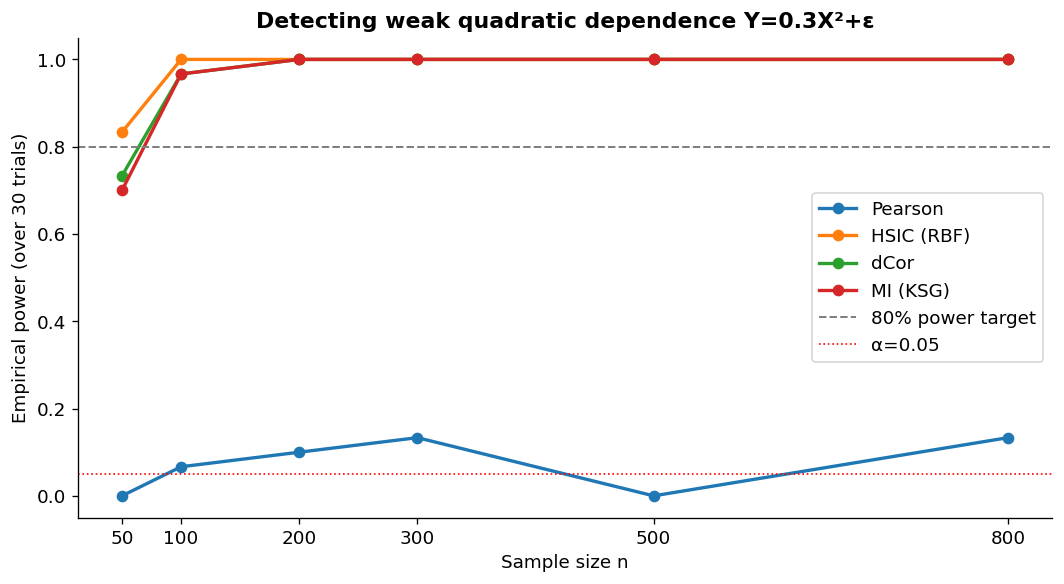

In [13]:
#Power curve: how many samples do we need to detect weak nonlinear dependence?
sample_sizes = [50, 100, 200, 300, 500, 800]
rng2 = np.random.default_rng(7)
n_trials = 30

methods = {
    'Pearson':     lambda x, y: stats.pearsonr(x, y)[1],
    'HSIC (RBF)':  lambda x, y: hsic(x, y, 'RBF', 'RBF', 100)[1],
    'dCor':        lambda x, y: distance_correlation_test(x, y, 100)[1],
    'MI (KSG)':    lambda x, y: mutual_information_test(x, y, n_perm=100)[1],
}

power = {m: [] for m in methods}
alpha = 0.05

for n in sample_sizes:
    trial_rejects = {m: 0 for m in methods}
    for _ in range(n_trials):
        x = rng2.uniform(-3, 3, n)
        y = 0.3 * x**2 + rng2.normal(0, 1, n)
        for m, fn in methods.items():
            if fn(x, y) < alpha:
                trial_rejects[m] += 1
    for m in methods:
        power[m].append(trial_rejects[m] / n_trials)

fig, ax = plt.subplots(figsize=(9, 5))
for (m, vals), color in zip(power.items(), COLORS):
    ax.plot(sample_sizes, vals, 'o-', label=m, color=color, linewidth=2)
ax.axhline(0.8, color='gray', ls='--', lw=1.2, label='80% power target')
ax.axhline(alpha, color='red', ls=':', lw=1, label=f'α={alpha}')
ax.set_xlabel('Sample size n')
ax.set_ylabel(f'Empirical power (over {n_trials} trials)')
ax.set_title('Detecting weak quadratic dependence Y=0.3X²+ε', fontweight='bold')
ax.legend()
ax.set_ylim(-0.05, 1.05)
ax.set_xticks(sample_sizes)
plt.tight_layout()
plt.show()


## 8 Sensitivity Analysis, Effect of Noise Level

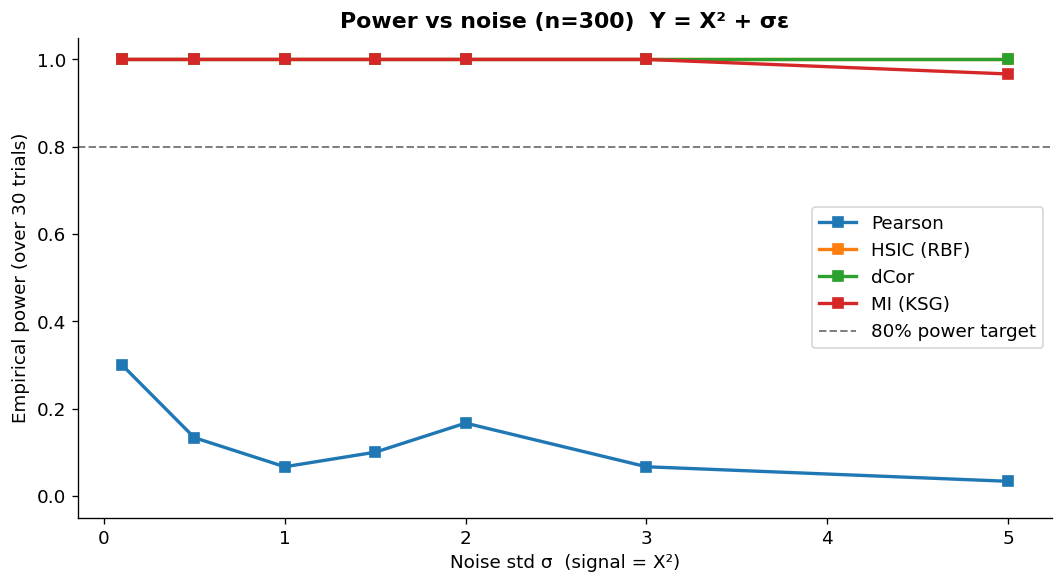

In [14]:
#Signal-to-noise ratio forY = X² + σε
sigmas = [0.1, 0.5, 1.0, 1.5, 2.0, 3.0, 5.0]
n = 300
n_trials = 30
rng3 = np.random.default_rng(13)

power_noise = {m: [] for m in methods}

for sig in sigmas:
    trial_rejects = {m: 0 for m in methods}
    for _ in range(n_trials):
        x = rng3.uniform(-3, 3, n)
        y = x**2 + rng3.normal(0, sig, n)
        for m, fn in methods.items():
            if fn(x, y) < 0.05:
                trial_rejects[m] += 1
    for m in methods:
        power_noise[m].append(trial_rejects[m] / n_trials)

fig, ax = plt.subplots(figsize=(9, 5))
for (m, vals), color in zip(power_noise.items(), COLORS):
    ax.plot(sigmas, vals, 's-', label=m, color=color, linewidth=2)
ax.axhline(0.8, color='gray', ls='--', lw=1.2, label='80% power target')
ax.set_xlabel('Noise std σ  (signal = X²)')
ax.set_ylabel(f'Empirical power (over {n_trials} trials)')
ax.set_title(f'Power vs noise (n={n})  Y = X² + σε', fontweight='bold')
ax.legend()
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()


## 9 Dashboard

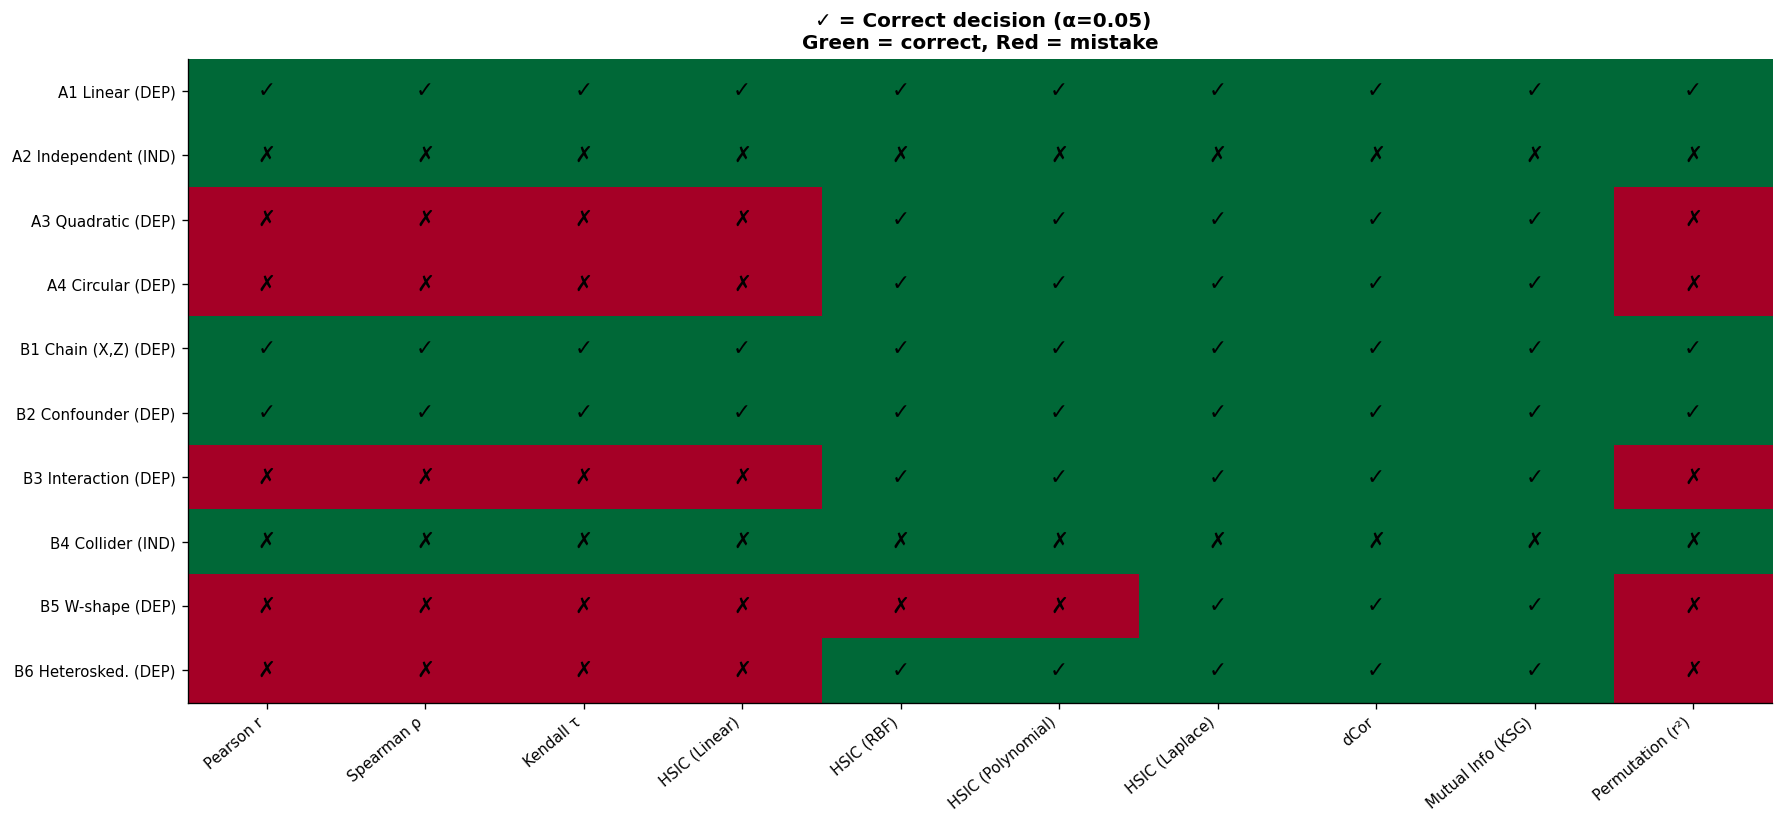


Accuracy per test:
HSIC (Laplace)       1.0
dCor                 1.0
Mutual Info (KSG)    1.0
HSIC (RBF)           0.9
HSIC (Polynomial)    0.9
Pearson r            0.5
Spearman ρ           0.5
Kendall τ            0.5
HSIC (Linear)        0.5
Permutation (r²)     0.5


In [15]:

all_scenarios = [
    ('A1 Linear',         A1_x, A1_y, True),
    ('A2 Independent',    A2_x, A2_y, False),
    ('A3 Quadratic',      A3_x, A3_y, True),
    ('A4 Circular',       A4_x, A4_y, True),
    ('B1 Chain (X,Z)',    B1_x, B1_z, True),
    ('B2 Confounder',     B2_x, B2_z, True),
    ('B3 Interaction',    B3_x, B3_z, True),
    ('B4 Collider',       B4_x, B4_y, False),
    ('B5 W-shape',        B5_x, B5_y, True),
    ('B6 Heterosked.',    B6_x, B6_y, True),
]

test_cols = [
    'Pearson r', 'Spearman ρ', 'Kendall τ',
    'HSIC (Linear)', 'HSIC (RBF)', 'HSIC (Polynomial)', 'HSIC (Laplace)',
    'dCor', 'Mutual Info (KSG)', 'Permutation (r²)', 'Partial Corr (Ω)'
]

decision_matrix = []
ground_truth = []

for sc_name, x, y, dep in all_scenarios:
    dm = np.column_stack([x, y])
    res = run_all_tests(x, y, data_matrix=dm, i=0, j=1, n_perm=300)
    row = res.set_index('Test')['Reject H₀ (α=0.05)'].to_dict()
    decision_matrix.append(row)
    ground_truth.append(dep)

dmat = pd.DataFrame(decision_matrix, index=[s[0] for s in all_scenarios])
dmat = dmat.reindex(columns=[c for c in test_cols if c in dmat.columns])

# Color coding: correct = green, wrong = red, truth shown on left
truth_series = pd.Series(ground_truth, index=dmat.index, name='Truth (dep?)')

color_mat = np.zeros_like(dmat.values, dtype=float)
for i, (truth, row) in enumerate(zip(ground_truth, dmat.values)):
    for j, val in enumerate(row):
        correct = (val == truth)
        color_mat[i, j] = 1.0 if correct else -1.0

fig, ax = plt.subplots(figsize=(15, 7))
im = ax.imshow(color_mat, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')

for i in range(color_mat.shape[0]):
    for j in range(color_mat.shape[1]):
        val = dmat.values[i, j]
        sym = '✓' if val else '✗'
        ax.text(j, i, sym, ha='center', va='center', fontsize=13,
                color='black')

ax.set_xticks(range(len(dmat.columns)))
ax.set_xticklabels(dmat.columns, rotation=40, ha='right', fontsize=9)
ax.set_yticks(range(len(dmat.index)))
ax.set_yticklabels([f"{idx} ({'DEP' if dep else 'IND'})" 
                    for idx, dep in zip(dmat.index, ground_truth)], fontsize=9)
ax.set_title(' ✓ = Correct decision (α=0.05)\n'
             'Green = correct, Red = mistake', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


acc = {}
for col in dmat.columns:
    correct = sum(dmat[col].iloc[i] == ground_truth[i] for i in range(len(ground_truth)))
    acc[col] = correct / len(ground_truth)
acc_df = pd.Series(acc, name='Accuracy').sort_values(ascending=False)
print('\nAccuracy per test:')
print(acc_df.to_string())

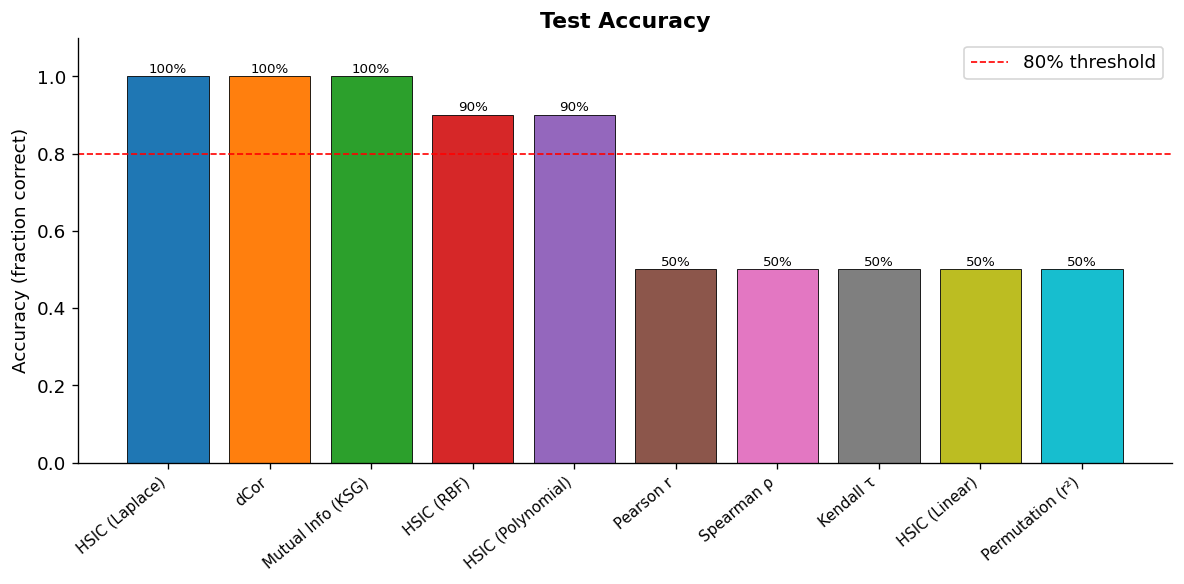

In [16]:

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(range(len(acc_df)), acc_df.values,
              color=[COLORS[i % 10] for i in range(len(acc_df))],
              edgecolor='black', linewidth=0.5)
ax.set_xticks(range(len(acc_df)))
ax.set_xticklabels(acc_df.index, rotation=40, ha='right', fontsize=9)
ax.set_ylabel('Accuracy (fraction correct)')
ax.set_ylim(0, 1.1)
ax.axhline(0.8, color='red', ls='--', lw=1, label='80% threshold')
ax.set_title('Test Accuracy', fontweight='bold')
ax.legend()
for bar, v in zip(bars, acc_df.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.01, f'{v:.0%}',
            ha='center', fontsize=8)
plt.tight_layout()
plt.show()


## 10 Summary

| Test | Strengths | Weaknesses | Best for |
|---|---|---|---|
| **Pearson r** | Fast, interpretable | Linear only | Gaussian / linear data |
| **Spearman / Kendall** | Handles monotone nonlinearity | Misses non-monotone | Ordinal, rank data |
| **HSIC (RBF/Laplace)** | General nonlinear, principled | Bandwidth choice, slow | Any continuous data |
| **HSIC (Linear)** | Equivalent to Pearson² | Linear only | Sanity check |
| **dCor** | General, unbiased estimator | O(n²) memory | Default nonlinear test |
| **Mutual Info (KSG)** | Model-free, info-theoretic | k-NN estimator variance | Complex dependencies |
| **Permutation** | No distributional assumptions | Computationally heavy | Any statistic |
| **Partial Corr (Ω)** | Controls for confounders | Assumes linearity, Gaussian | Causal structure analysis |

###  Takeaways

1. **No single test dominates** ensemble agreement is best practice.
2. **Pearson fails** on quadratic, circular, and heteroskedastic relationships.
3. **HSIC with RBF/Laplace kernels** is most robust across relationship types.
4. **Partial correlation** is essential when confounders or mediators exist.
5. **Colliders** create spurious conditional dependencies ; watch out for Berkson's bias.
6. **Power grows** with n; for n<100 you need very strong signals to detect nonlinear deps reliably.